# Pipeline completo - análise e previsão de qualidade dos vinhos
### Tech Challenge Fase 2 | POSTECH | 2026


**Base de dados:** github -> data/raw.csv
**Problema:** Análise - Alta Qualidade: nota ≥ 7 | Baixa/Média: nota < 7


## 1. Importação de Bibliotecas

In [1]:
# bibliotecas
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Exibir os gráficos inline no notebook
%matplotlib inline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# mapeamento dos caminhos de saída para facilitar a escrita
BASE = '..'
GRAF = os.path.join(BASE, 'resultados', 'graficos')
DADOS = os.path.join(BASE, 'dados')
RESULT = os.path.join(BASE, 'resultados')
for d in [GRAF, DADOS, RESULT]:
    os.makedirs(d, exist_ok=True)

# padronização dos estilos de gráfico
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')

## 2. Carregamento dos Dados

In [4]:
# dataset bruta
df = pd.read_csv('C:/Users/Talles.DESKTOP-ETH2HQM/OneDrive/Documentos/PÓS TECH/FIAP/Fase 2/Tech Challenge/wine_project/data/raw.csv')

# A coluna "Id" é apenas um identificador; vamos removê-la da análise.
if 'Id' in df.columns:
    df.drop(columns='Id', inplace=True)

## 3. Análise Exploratória de Dados (EDA)

### 3.1 Estatísticas Descritivas

In [5]:
# Estatísticas descritivas 
desc = df.describe().T
desc.to_csv(os.path.join(RESULT, 'estatisticas_descritivas.csv'))
desc

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


### 3.2 Verificação de Dados Faltantes e Duplicados

In [6]:
faltantes = df.isnull().sum()
duplicados = df.duplicated().sum()
print(f'\nLinhas duplicadas: {duplicados}')


Linhas duplicadas: 125


### 3.3 Distribuição da Variável Alvo

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


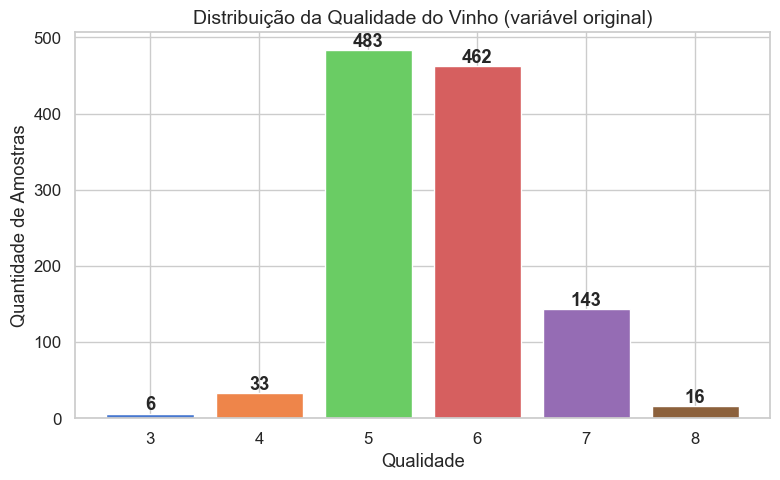

In [7]:
# distribuição da variável alvo (quality)
dist_quality = df['quality'].value_counts().sort_index()
print(dist_quality)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dist_quality.index.astype(str), dist_quality.values, color=COLORS[:len(dist_quality)])
for bar, val in zip(bars, dist_quality.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Distribuição da Qualidade do Vinho (variável original)', fontsize=14)
ax.set_xlabel('Qualidade')
ax.set_ylabel('Quantidade de Amostras')
plt.tight_layout()
plt.savefig(os.path.join(GRAF, '01_distribuicao_quality.png'), dpi=150)
plt.show()

### 3.4 Histogramas das Features

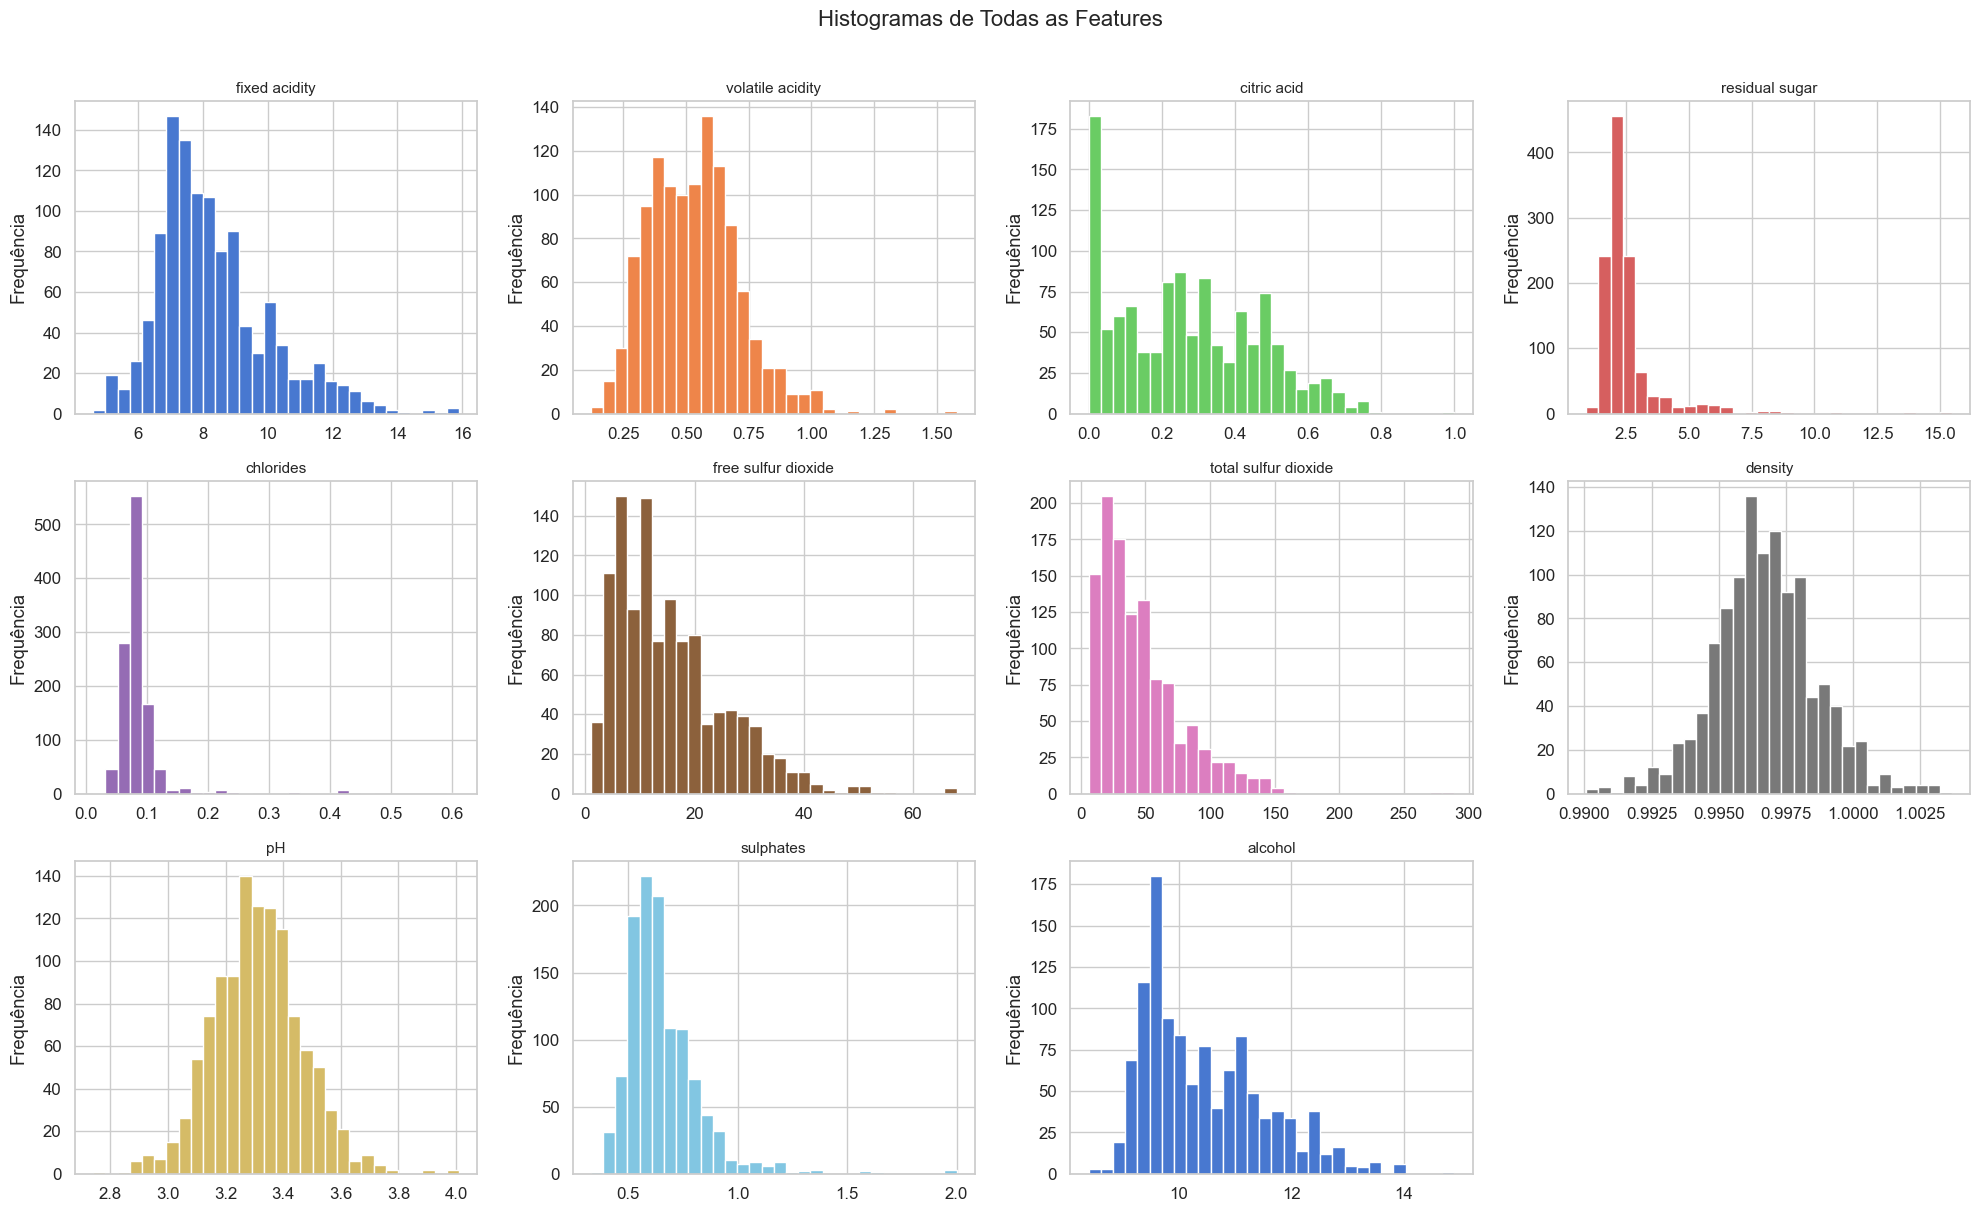

In [8]:
# histograma
features = [c for c in df.columns if c != 'quality']
n_feat = len(features)
ncols = 4
nrows = (n_feat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color=COLORS[i % len(COLORS)], edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frequência')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Histogramas de Todas as Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAF, '02_histogramas_features.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.5 heatmap

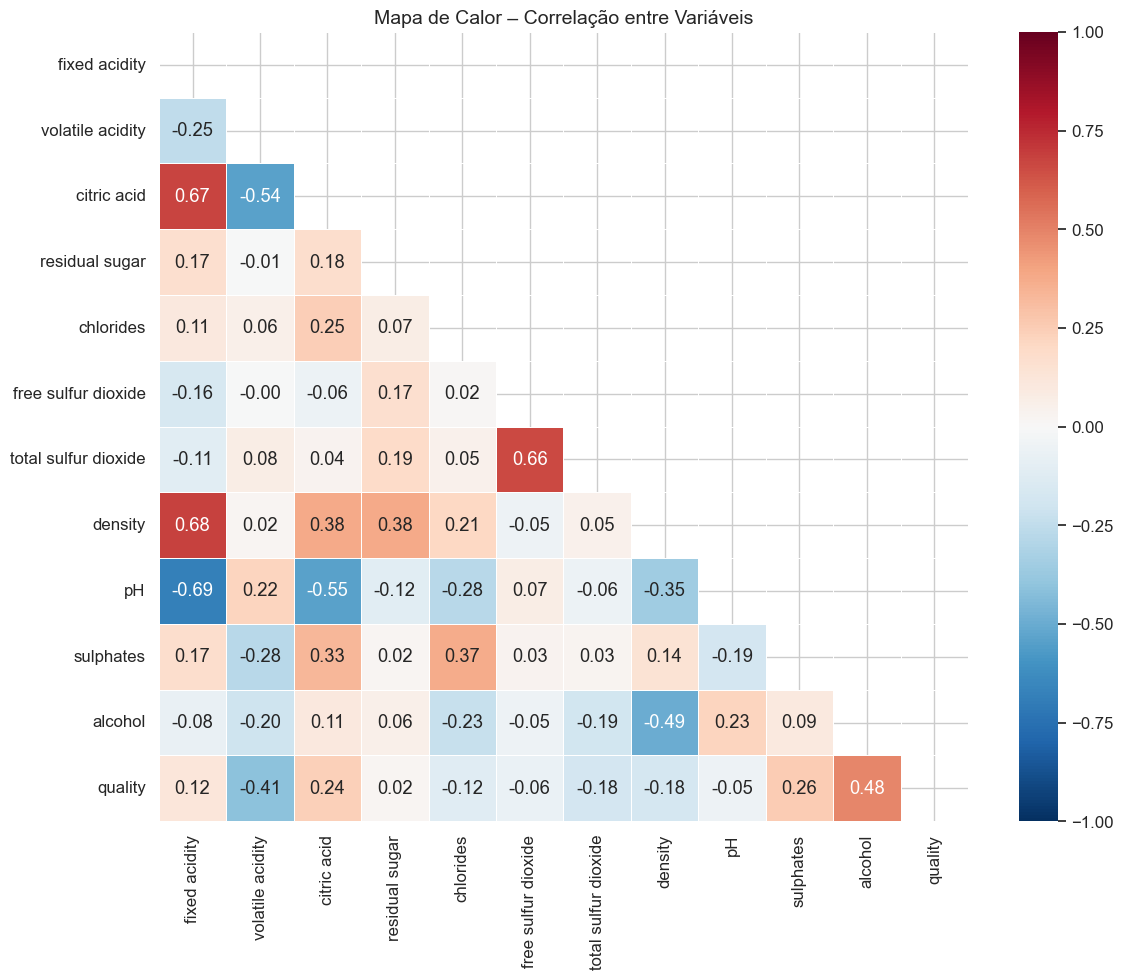

In [9]:
# heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Mapa de Calor – Correlação entre Variáveis', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(GRAF, '03_heatmap_correlacao.png'), dpi=150)
plt.show()

### 3.6 Pizza das Classes

--- Balanceamento da Classe Binária ---
  0 (Baixa/Média – quality < 7): 984 (86.1%)
  1 (Alta – quality >= 7):        159 (13.9%)


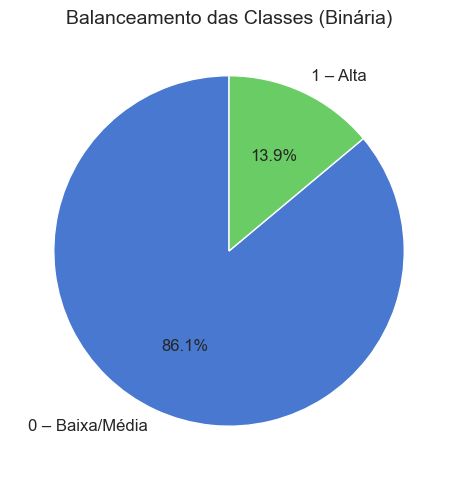

In [10]:
# Pizza das classes

df_temp = df.copy()
df_temp['qualidade_binaria'] = (df_temp['quality'] >= 7).astype(int)
bal = df_temp['qualidade_binaria'].value_counts()
print('--- Balanceamento da Classe Binária ---')
print(f'  0 (Baixa/Média – quality < 7): {bal.get(0, 0)} ({bal.get(0,0)/len(df_temp)*100:.1f}%)')
print(f'  1 (Alta – quality >= 7):        {bal.get(1, 0)} ({bal.get(1,0)/len(df_temp)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 5))
labels = ['0 – Baixa/Média', '1 – Alta']
sizes = [bal.get(0, 0), bal.get(1, 0)]
colors_pie = [COLORS[0], COLORS[2]]
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                   colors=colors_pie, startangle=90,
                                   textprops={'fontsize': 12})
ax.set_title('Balanceamento das Classes (Binária)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(GRAF, '05_balanceamento_classes.png'), dpi=150)
plt.show()

## 4. Limpeza e pré-processamento

### 4.1 Remoção de Duplicadas

In [11]:
# remover duplicados
tamanho_antes = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicados: {tamanho_antes - len(df)}')

Duplicados: 125


### 4.2 Transformação da Variável Alvo em Binária

In [12]:
# variável alvo binária
# Regra: quality >= 7 → 1 (Alta)  |  quality < 7 → 0 (Baixa/Média)
df['qualidade_bin'] = (df['quality'] >= 7).astype(int)
print('Variável alvo binária criada: "qualidade_bin"')
print(df['qualidade_bin'].value_counts())

# Separar features (X) e alvo (y)
X = df.drop(columns=['quality', 'qualidade_bin'])
y = df['qualidade_bin']
feature_names = list(X.columns)
print(f'\nFeatures ({len(feature_names)}): {feature_names}')

Variável alvo binária criada: "qualidade_bin"
qualidade_bin
0    881
1    137
Name: count, dtype: int64

Features (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### 4.3 Normalização das Features

In [13]:
# StandardScaler 
# transforma cada feature para média=0 e desvio-padrão=1.

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names, index=X.index)
print('Features normalizadas com StandardScaler.')

# salvamento
df_limpo = X_scaled.copy()
df_limpo['qualidade_bin'] = y.values
df_limpo.to_csv('../dados/wine_limpo.csv', index=False)

X_scaled.head()

Features normalizadas com StandardScaler.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.510499,0.909227,-1.370507,-0.475125,-0.230739,-0.457043,-0.372294,0.574517,1.258719,-0.578153,-0.961563
1,-0.280676,1.892418,-1.370507,0.057517,0.223040,0.919349,0.624466,0.052448,-0.707068,0.138438,-0.596108
2,-0.280676,1.236957,-1.166564,-0.170758,0.099282,-0.063788,0.231803,0.156862,-0.326593,-0.040710,-0.596108
3,1.672822,-1.384886,1.484700,-0.475125,-0.251365,0.132839,0.413032,0.678931,-0.960718,-0.458721,-0.596108
5,-0.510499,0.690740,-1.370507,-0.551216,-0.251365,-0.260415,-0.191065,0.574517,1.258719,-0.578153,-0.961563


## 5. Divisão Treino e Teste

In [14]:
# treino / teste 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,       # 20% para teste
    random_state=42,      # Reprodutibilidade
    stratify=y            # Manter proporção das classes
)

#visual geral para organização
print(f'Conjunto de TREINO: {X_train.shape[0]} amostras')
print(f'  Classe 0 (Baixa/Média): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)')
print(f'  Classe 1 (Alta):         {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)')
print(f'\nConjunto de TESTE:  {X_test.shape[0]} amostras')
print(f'  Classe 0 (Baixa/Média): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)')
print(f'  Classe 1 (Alta):         {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)')

Conjunto de TREINO: 814 amostras
  Classe 0 (Baixa/Média): 704 (86.5%)
  Classe 1 (Alta):         110 (13.5%)

Conjunto de TESTE:  204 amostras
  Classe 0 (Baixa/Média): 177 (86.8%)
  Classe 1 (Alta):         27 (13.2%)


## 6. Treinamento dos Modelos

In [15]:
# Dicionário para armazenar os modelos treinados
modelos = {}

### 6.1 Regressão Logística

In [16]:
# ── Regressão Logística 
print('Regressão Logística...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
modelos['Regressão Logística'] = lr

Regressão Logística...


### 6.2 Random Forest

In [17]:
#Random Forest 
print('Random Forest')
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
modelos['Random Forest'] = rf


Random Forest


### 6.3 Gradient Boosting

In [18]:
# ── Gradient Boosting ────────────────────────────────────────────────────────
print('Gradient Boosting')
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=3, random_state=42)
gb.fit(X_train, y_train)
modelos['Gradient Boosting'] = gb


Gradient Boosting


## 7. Avaliação e Comparação dos Modelos

### 7.1 Métricas por Modelo

In [20]:
#Calcular as métricas 
resultados = []
predicoes = {}

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    predicoes[nome] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    resultados.append({
        'Modelo': nome,
        'Acurácia': round(acc, 4),
        'Precisão': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

    print(f'\n {nome} ')
    print(f'  Acurácia : {acc:.4f}')
    print(f'  Precisão : {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')


 Regressão Logística 
  Acurácia : 0.8971
  Precisão : 0.6500
  Recall   : 0.4815
  F1-Score : 0.5532
  ROC-AUC  : 0.8860

 Random Forest 
  Acurácia : 0.9167
  Precisão : 0.7778
  Recall   : 0.5185
  F1-Score : 0.6222
  ROC-AUC  : 0.9064

 Gradient Boosting 
  Acurácia : 0.8775
  Precisão : 0.5500
  Recall   : 0.4074
  F1-Score : 0.4681
  ROC-AUC  : 0.8797


### 7.2 Matriz de Confusão

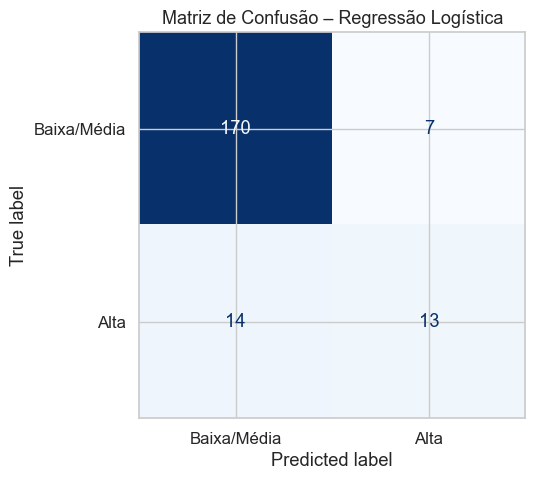

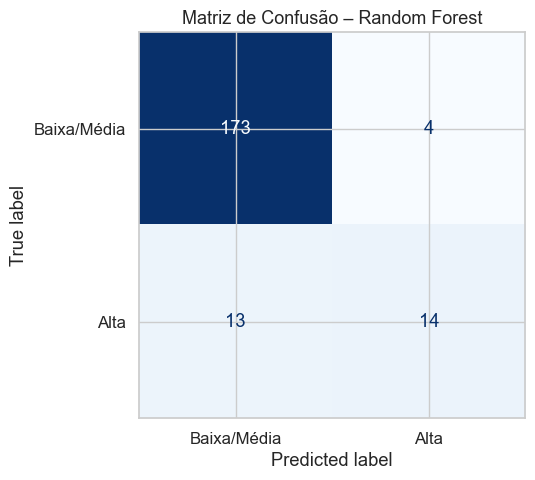

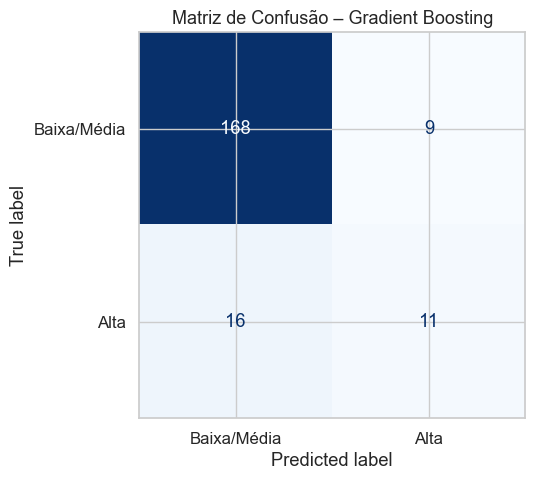

In [21]:
#Matriz de confusão para cada um
for nome, y_pred in predicoes.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Baixa/Média', 'Alta'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusão – {nome}', fontsize=13)
    plt.tight_layout()
    fname = f'06_matriz_confusao_{nome.lower().replace(" ", "_")}.png'
    plt.savefig(os.path.join(GRAF, fname), dpi=150)
    plt.show()

### 7.3 Curvas ROC

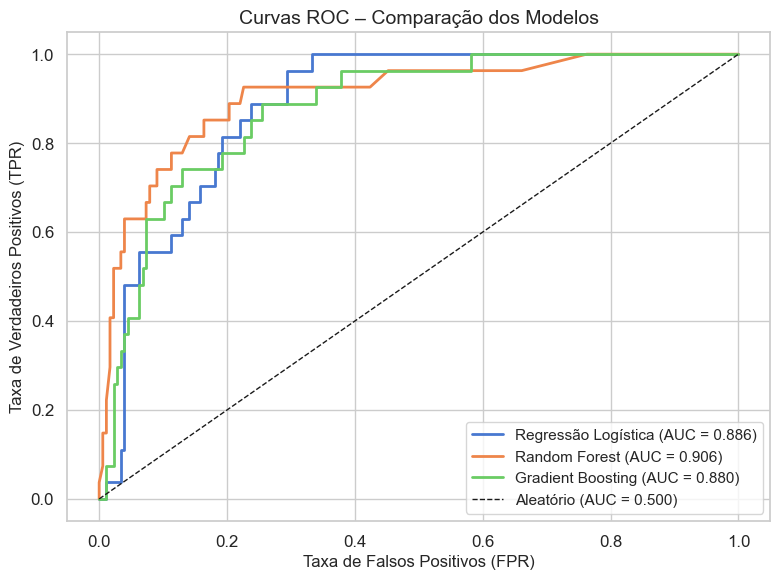

In [22]:
# curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
for i, (nome, modelo) in enumerate(modelos.items()):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{nome} (AUC = {auc_val:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.500)')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC – Comparação dos Modelos', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(GRAF, '07_curvas_roc.png'), dpi=150)
plt.show()

### 7.4 Tabela Comparativa 

In [23]:
# Comparativo
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(os.path.join(RESULT, 'comparacao_modelos.csv'), index=False)
print('--- Tabela Comparativa ---')
df_resultados

--- Tabela Comparativa ---


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
0,Regressão Logística,0.8971,0.6500,0.4815,0.5532,0.8860
1,Random Forest,0.9167,0.7778,0.5185,0.6222,0.9064
2,Gradient Boosting,0.8775,0.5500,0.4074,0.4681,0.8797


## 8. Interpretação final dos resultados

### 8.1 Feature Importance — Quais variáveis mais influenciam a qualidade?

Melhor modelo (pelo F1-Score): Random Forest

--- Top 5 Features Mais Importantes ---
                citric acid : 0.0948
                    density : 0.1023
                  sulphates : 0.1147
           volatile acidity : 0.1189
                    alcohol : 0.1622


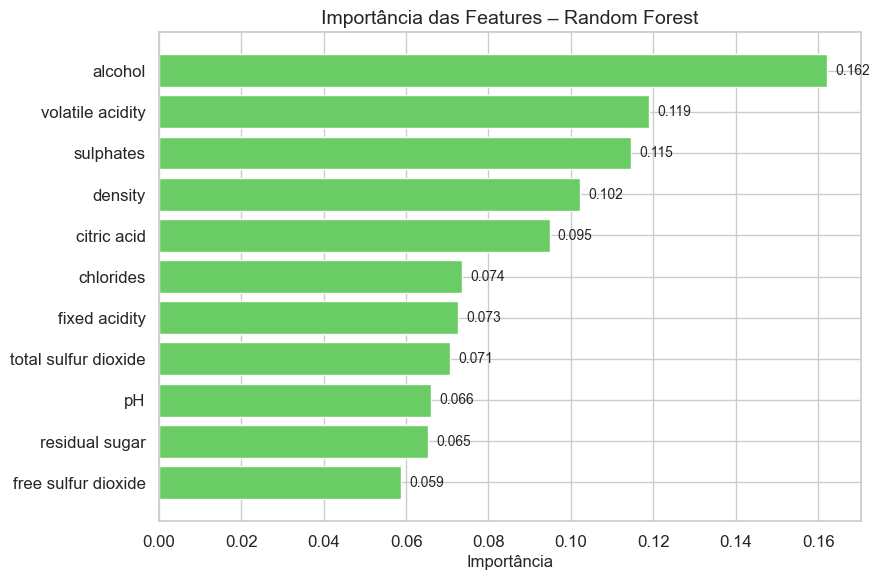

In [24]:
# Identificar o melhor modelo (pelo F1-Score)
idx_melhor = df_resultados['F1-Score'].idxmax()
melhor_nome = df_resultados.loc[idx_melhor, 'Modelo']
melhor_modelo = modelos[melhor_nome]
print(f'Melhor modelo (pelo F1-Score): {melhor_nome}')

# Feature Importance 
if hasattr(melhor_modelo, 'feature_importances_'):
    importancias = melhor_modelo.feature_importances_
else:
    # Para Regressão Logística, usamos o valor absoluto dos coeficientes
    importancias = np.abs(melhor_modelo.coef_[0])

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importância': importancias
}).sort_values('Importância', ascending=True)

# Top 5
top5 = df_imp.tail(5)
print('\n--- Top 5 Features Mais Importantes ---')
for _, row in top5.iterrows():
    print(f'  {row["Feature"]:>25s} : {row["Importância"]:.4f}')

# Gráfico de barras horizontais
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(df_imp['Feature'], df_imp['Importância'], color=COLORS[2])
ax.set_xlabel('Importância', fontsize=12)
ax.set_title(f'Importância das Features – {melhor_nome}', fontsize=14)
for i, (val, name) in enumerate(zip(df_imp['Importância'], df_imp['Feature'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(GRAF, '08_feature_importance.png'), dpi=150)
plt.show()

### 8.2 Insights e Conclusões

In [ ]:
# texto final - avaliação

# anotação - O que isso significa na prática - apresentação interdisciplinar, cruzando dados com conhecimento sobre vinhos, já que a apresentação tem como alvo diretores/gestores.

#TOP
top5_list = list(top5['Feature'].values[::-1])  # do mais importante para o menos

insights = f"""
## Análise e Insights – Qualidade do Vinho

### Melhor Modelo: {melhor_nome}

O modelo **{melhor_nome}** apresentou o melhor desempenho, avaliado
pelo F1-Score, que equilibra precisão e recall – métricas especialmente
importantes quando as classes estão desbalanceadas.

### As 5 Características Mais Importantes

1. **{top5_list[0]}**
2. **{top5_list[1]}**
3. **{top5_list[2]}**
4. **{top5_list[3]}**
5. **{top5_list[4]}**

### O que isso significa na prática?

- **alcohol (teor alcoólico):** Vinhos com maior teor alcoólico tendem a ser
  classificados com qualidade mais alta. Isso está relacionado à maturação
  mais completa das uvas.

- **volatile acidity (acidez volátil):** Níveis elevados de acidez volátil
  (ácido acético) indicam deterioração e estão associados a vinhos de menor
  qualidade. Quanto menor, melhor.

- **sulphates (sulfatos):** Sulfatos contribuem para a conservação e podem
  realçar sabores. Níveis adequados estão ligados a maior qualidade.

- **citric acid (ácido cítrico):** Adiciona frescor e sabor ao vinho.
  Quantidades moderadas estão associadas a melhor percepção de qualidade.

- **total sulfur dioxide (dióxido de enxofre total):** Usado como conservante;
  em excesso, pode gerar sabores desagradáveis e prejudicar a qualidade.

### Recomendação

Para um sistema de classificação em produção, recomendo o **{melhor_nome}**
por apresentar o melhor equilíbrio entre todas as métricas avaliadas.
Ele captura padrões complexos nos dados enquanto mantém boa capacidade de
generalização.
"""

print(insights)


## Análise e Insights – Qualidade do Vinho

### Melhor Modelo: Random Forest

O modelo **Random Forest** apresentou o melhor desempenho geral, avaliado
pelo F1-Score, que equilibra precisão e recall – métricas especialmente
importantes quando as classes estão desbalanceadas.

### As 5 Características Mais Importantes

1. **alcohol**
2. **volatile acidity**
3. **sulphates**
4. **density**
5. **citric acid**

### O que isso significa na prática?

- **alcohol (teor alcoólico):** Vinhos com maior teor alcoólico tendem a ser
  classificados com qualidade mais alta. Isso está relacionado à maturação
  mais completa das uvas.

- **volatile acidity (acidez volátil):** Níveis elevados de acidez volátil
  (ácido acético) indicam deterioração e estão associados a vinhos de menor
  qualidade. Quanto menor, melhor.

- **sulphates (sulfatos):** Sulfatos contribuem para a conservação e podem
  realçar sabores. Níveis adequados estão ligados a maior qualidade.

- **citric acid (ácido cítrico):** Adic

## Conclusão

O modelo **Random Forest** foi o melhor classificador, atingindo:
- **Acurácia:** 91,67%
- **F1-Score:** 0.6222
- **ROC-AUC:** 0.9064

As três características físico-químicas mais determinantes foram:
1. Teor Alcoólico (alcohol)
2. Acidez Volátil (volatile acidity)
3. Sulfatos (sulphates)